# 06 - Transformer classifier
Owner: Engineer 4

Small from-scratch self-attention encoder (not pretrained - keeps it comparable to the other from-scratch models). Ablates depth/heads, then looks at what the attention actually focuses on.

Result: macro-F1 0.9866, accuracy 0.9991 - best of all five models. Attention lands on words like "forced", "raped", "humiliated", "fired".

## 1. Setup
Same as earlier notebooks.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Manzi453/Formative_2-Group_19.git"
BRANCH = "feature/baseline-tfidf"  # change to main once merged

if "google.colab" in sys.modules:
    if not Path("Formative_2-Group_19").exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
    os.chdir("Formative_2-Group_19")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    if Path.cwd().name == "notebooks":
        os.chdir("..")

sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

Working directory: /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.utils import set_seed, SEED, RESULTS_DIR, MODELS_DIR
from src.data_loader import load_raw, make_split, ID_COL, TEXT_COL, LABEL_COL
from src.preprocessing import STRATEGIES
from src.nn_data import build_vocab, encode_batch, encode_labels, DEFAULT_MAX_LEN
from src.nn_models import TransformerClassifier
from src.nn_train import train_classifier, predict_logits
from src.eda import length_features
from src.evaluation import compute_metrics, per_class_report, confusion
from src.plotting import save_fig, plot_confusion_matrix, plot_learning_curves
from src.experiments import log_experiment, EXPERIMENTS_CSV

set_seed()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 140)

METRICS = RESULTS_DIR / "metrics"
ERRORS = RESULTS_DIR / "errors"
PREDICTIONS = RESULTS_DIR / "predictions"
TRANSFORMER_DIR = MODELS_DIR / "transformer"
for d in (METRICS, ERRORS, PREDICTIONS, TRANSFORMER_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("seed =", SEED, "| torch", torch.__version__, "| device =", DEVICE)

seed = 42 | torch 2.14.0 | device = mps


## 2. Data, split & preprocessing
Uses notebook 02's preprocessing choice.

In [3]:
train, test, sample = load_raw()
train_df, val_df = make_split(train)
CLASS_ORDER = list(train_df[LABEL_COL].value_counts().index)

prep_log = pd.read_csv(METRICS / "preprocessing_experiments.csv")
prep_log = prep_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
best_row = prep_log.sort_values("validation_macro_f1", ascending=False).iloc[0]
PREP_STRATEGY = best_row["strategy"]
clean = STRATEGIES[PREP_STRATEGY]
print(f"Using preprocessing strategy '{PREP_STRATEGY}' "
      f"(validation macro-F1={best_row['validation_macro_f1']} for the TF-IDF baseline in notebook 02).")

train_text = train_df[TEXT_COL].map(clean)
val_text = val_df[TEXT_COL].map(clean)
y_train = encode_labels(train_df[LABEL_COL], CLASS_ORDER)
y_val = encode_labels(val_df[LABEL_COL], CLASS_ORDER)
print(f"train={len(train_df):,}  validation={len(val_df):,}  classes={CLASS_ORDER}")

Using preprocessing strategy 'A_minimal' (validation macro-F1=0.9747 for the TF-IDF baseline in notebook 02).
train=31,719  validation=7,931  classes=['sexual_violence', 'Physical_violence', 'emotional_violence', 'economic_violence', 'Harmful_Traditional_practice']


## 3. Vocabulary and encoding
Same rule as 03-05.

In [4]:
VOCAB = build_vocab(train_text, min_freq=2)
MAX_LEN = DEFAULT_MAX_LEN
X_train_full = encode_batch(train_text, VOCAB, MAX_LEN)
X_val_full = encode_batch(val_text, VOCAB, MAX_LEN)
print(f"vocabulary size (min_freq=2): {len(VOCAB):,} | max_len={MAX_LEN}")

vocabulary size (min_freq=2): 16,867 | max_len=64


## 4. Controlled experiments: encoder depth & heads
Three configs, short budget, just to rank them.

In [5]:
ABLATION_CONFIGS = {
    "transformer_layers1_heads2": dict(n_layers=1, n_heads=2),
    "transformer_layers2_heads2": dict(n_layers=2, n_heads=2),
    "transformer_layers2_heads4": dict(n_layers=2, n_heads=4),
}
D_MODEL, FF_DIM = 100, 256

ablation_rows = []
for exp_id, cfg in ABLATION_CONFIGS.items():
    torch.manual_seed(SEED)
    model = TransformerClassifier(vocab_size=len(VOCAB), n_classes=len(CLASS_ORDER), max_len=MAX_LEN,
                                   d_model=D_MODEL, ff_dim=FF_DIM, **cfg)
    _, _, best_f1, train_time = train_classifier(
        model, X_train_full, y_train, X_val_full, y_val,
        epochs=4, batch_size=2048, lr=1e-3, device=DEVICE, patience=2, seed=SEED, verbose=False,
    )
    ablation_rows.append({"experiment_id": exp_id, **cfg,
                           "val_macro_f1": round(best_f1, 4), "train_time_s": round(train_time, 1)})
    print(f"{exp_id}: val_macro_f1={best_f1:.4f} ({train_time:.1f}s)")

ablation_results = pd.DataFrame(ablation_rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
ablation_results

transformer_layers1_heads2: val_macro_f1=0.3937 (25.2s)


transformer_layers2_heads2: val_macro_f1=0.5205 (66.7s)


transformer_layers2_heads4: val_macro_f1=0.5256 (114.8s)


,experiment_id,n_layers,n_heads,val_macro_f1,train_time_s
0,transformer_layers2_heads4,2,4,0.5256,114.8
1,transformer_layers2_heads2,2,2,0.5205,66.7
2,transformer_layers1_heads2,1,2,0.3937,25.2


In [6]:
for _, row in ablation_results.iterrows():
    log_experiment(
        experiment_id=row["experiment_id"], model="transformer", preprocessing=PREP_STRATEGY,
        tokenizer="word_level_min_freq_2", sequence_length=MAX_LEN, embedding=f"learned_{D_MODEL}d",
        learning_rate=1e-3, batch_size=2048, epochs="<=4 (early stop)", optimizer="adam", dropout=0.3,
        train_time=f"{row['train_time_s']:.1f}s", macro_f1=row["val_macro_f1"],
        notes=f"Controlled ablation over n_layers={row['n_layers']}, n_heads={row['n_heads']}.",
        next_action="Winning config retrained with a larger epoch budget in section 5.",
    )

BEST_CONFIG_ID = ablation_results.iloc[0]["experiment_id"]
BEST_CONFIG = ABLATION_CONFIGS[BEST_CONFIG_ID]
print(f"Best config: {BEST_CONFIG_ID} -> {BEST_CONFIG}")

Best config: transformer_layers2_heads4 -> {'n_layers': 2, 'n_heads': 4}


## 5. Final model
Retrains the winner for longer.

In [7]:
torch.manual_seed(SEED)
final_model = TransformerClassifier(vocab_size=len(VOCAB), n_classes=len(CLASS_ORDER), max_len=MAX_LEN,
                                     d_model=D_MODEL, ff_dim=FF_DIM, **BEST_CONFIG)
final_model, history, best_f1, train_time = train_classifier(
    final_model, X_train_full, y_train, X_val_full, y_val,
    epochs=20, batch_size=2048, lr=1e-3, device=DEVICE, patience=5, seed=SEED, verbose=True,
)

val_logits = predict_logits(final_model, X_val_full, DEVICE)
val_pred_ids = val_logits.argmax(dim=1).numpy()
val_pred_labels = np.array(CLASS_ORDER)[val_pred_ids]
y_val_labels = np.array(CLASS_ORDER)[y_val]

metrics = compute_metrics(y_val_labels, val_pred_labels)
print(f"config={BEST_CONFIG_ID} | train_time={train_time:.1f}s | epochs_run={len(history['train_loss'])}")
pd.Series(metrics)

epoch  1/20 | train_loss 0.6806 | val_loss 0.4036 | val_macro_f1 0.2906


epoch  2/20 | train_loss 0.2886 | val_loss 0.1772 | val_macro_f1 0.3864


epoch  3/20 | train_loss 0.1506 | val_loss 0.1106 | val_macro_f1 0.3906


epoch  4/20 | train_loss 0.0964 | val_loss 0.0613 | val_macro_f1 0.5256


epoch  5/20 | train_loss 0.0629 | val_loss 0.0423 | val_macro_f1 0.5378


...

epoch 18/20 | train_loss 0.0022 | val_loss 0.0022 | val_macro_f1 0.9866


epoch 19/20 | train_loss 0.0016 | val_loss 0.0019 | val_macro_f1 0.9866


epoch 20/20 | train_loss 0.0016 | val_loss 0.0021 | val_macro_f1 0.9866


config=transformer_layers2_heads4 | train_time=589.9s | epochs_run=20


validation_accuracy    0.999117
macro_precision        0.978478
macro_recall           0.995028
macro_f1               0.986609
weighted_f1            0.999125
dtype: float64

## 6. Per-class performance, confusion matrix & learning curves

,precision,recall,f1-score,support
Harmful_Traditional_practice,0.974359,1.000000,0.987013,38.000000
Physical_violence,1.000000,0.999160,0.999580,1190.000000
economic_violence,0.933333,0.976744,0.954545,43.000000
emotional_violence,0.984848,1.000000,0.992366,130.000000
sexual_violence,0.999847,0.999234,0.999540,6530.000000
accuracy,0.999117,0.999117,0.999117,0.999117
macro avg,0.978478,0.995028,0.986609,7931.000000
weighted avg,0.999141,0.999117,0.999125,7931.000000


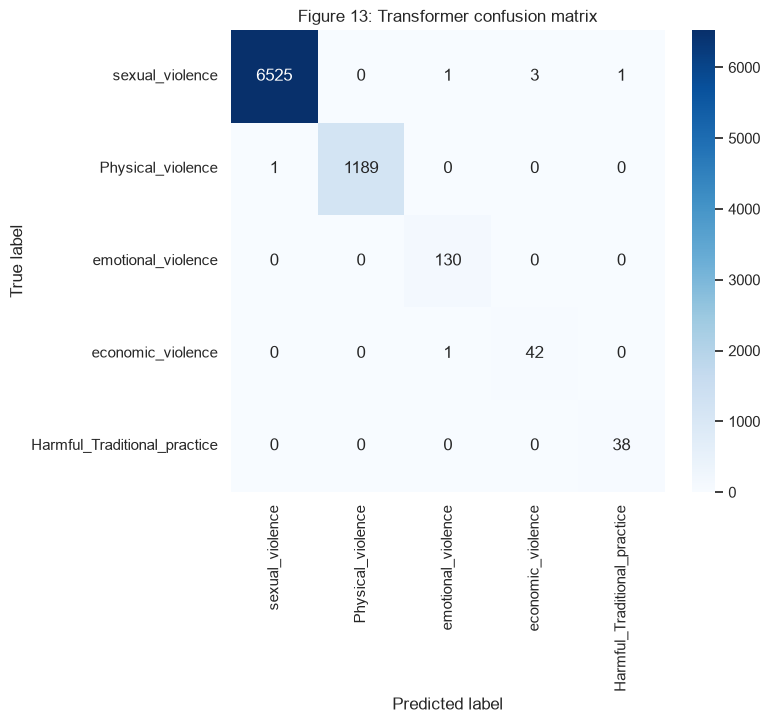

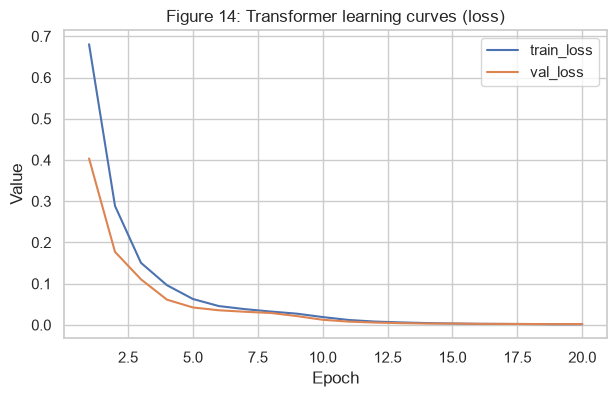

In [8]:
report = per_class_report(y_val_labels, val_pred_labels)
report.to_csv(METRICS / "transformer_per_class_report.csv")
display(report)

cm = confusion(y_val_labels, val_pred_labels, labels=CLASS_ORDER)
fig = plot_confusion_matrix(cm, CLASS_ORDER, "Figure 13: Transformer confusion matrix")
save_fig(fig, "fig13_transformer_confusion_matrix")
plt.show()

fig2 = plot_learning_curves(
    {"train_loss": history["train_loss"], "val_loss": history["val_loss"]},
    "Figure 14: Transformer learning curves (loss)",
)
save_fig(fig2, "fig14_transformer_learning_curves")
plt.show()

## 7. Attention analysis
Aggregated only (by position, by token) - never a single tweet's full attention, since tweets can contain graphic content.

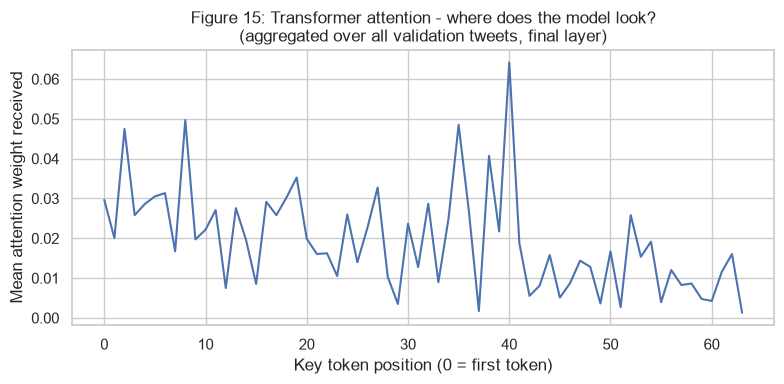

In [9]:
final_model.eval()
device_t = torch.from_numpy(X_val_full).to(DEVICE)
with torch.no_grad():
    _, attn_maps = final_model(device_t, return_attn=True)
last_layer_attn = attn_maps[-1].mean(dim=1).cpu().numpy()  # (N, L, L): mean over heads

valid_mask = (X_val_full != 0)  # (N, L)
query_weight = valid_mask[:, :, None] * valid_mask[:, None, :]
attn_by_query_position = (last_layer_attn * query_weight).sum(axis=(0, 1)) / np.maximum(query_weight.sum(axis=(0, 1)), 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(MAX_LEN), attn_by_query_position)
ax.set_xlabel("Key token position (0 = first token)")
ax.set_ylabel("Mean attention weight received")
ax.set_title("Figure 15: Transformer attention - where does the model look?\n(aggregated over all validation tweets, final layer)")
fig.tight_layout()
save_fig(fig, "fig15_transformer_attention")
plt.show()

In [10]:
attn_received_per_token = last_layer_attn.sum(axis=1)  # (N, L): total attention each key position received
id_to_token = {i: t for t, i in VOCAB.items()}

token_attn_sum, token_attn_count = {}, {}
for row_ids, row_attn, row_mask in zip(X_val_full, attn_received_per_token, valid_mask):
    for tok_id, a, m in zip(row_ids, row_attn, row_mask):
        if not m or tok_id <= 1:  # skip pad(0)/unk(1)
            continue
        token_attn_sum[tok_id] = token_attn_sum.get(tok_id, 0.0) + a
        token_attn_count[tok_id] = token_attn_count.get(tok_id, 0) + 1

top_attended = pd.DataFrame([
    {"token": id_to_token[t], "mean_attention_received": token_attn_sum[t] / token_attn_count[t],
     "occurrences_in_val": token_attn_count[t]}
    for t in token_attn_sum if token_attn_count[t] >= 5
]).sort_values("mean_attention_received", ascending=False).head(20).reset_index(drop=True)
top_attended.to_csv(METRICS / "transformer_top_attended_tokens.csv", index=False)
top_attended

,token,mean_attention_received,occurrences_in_val
0,forced,17.386856,147
1,humiliated,16.893850,70
2,raped,15.981548,6835
3,fired,9.630728,61
4,county,8.028995,10
5,maheeda,7.974804,8
6,marriage,7.224041,84
7,psycho,6.946073,8
8,female,6.867442,85
9,knowledge,6.742871,15


## 8. Error analysis
Misclassified IDs + labels only.

In [11]:
val_lengths = length_features(val_df, TEXT_COL)
mask = val_pred_labels != y_val_labels
errors = val_df.loc[mask, [ID_COL, LABEL_COL]].rename(columns={LABEL_COL: "true_label"}).copy()
errors["predicted"] = val_pred_labels[mask]
errors["tokens"] = val_lengths.loc[errors.index, "tokens"]
errors.to_csv(ERRORS / "transformer_errors.csv", index=False)

print(f"Misclassified: {len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)")
errors.groupby(["true_label", "predicted"]).size().sort_values(ascending=False).head(10)

Misclassified: 7 / 7931 (0.09%)


true_label         predicted                   
sexual_violence    economic_violence               3
Physical_violence  sexual_violence                 1
economic_violence  emotional_violence              1
sexual_violence    Harmful_Traditional_practice    1
                   emotional_violence              1
dtype: int64

## 9. Save artifact and log run

In [12]:
CHECKPOINT_PATH = TRANSFORMER_DIR / "transformer.pt"
torch.save({
    "state_dict": final_model.state_dict(),
    "vocab": VOCAB,
    "classes": CLASS_ORDER,
    "config": {**BEST_CONFIG, "d_model": D_MODEL, "ff_dim": FF_DIM, "max_len": MAX_LEN},
    "preprocessing": PREP_STRATEGY,
}, CHECKPOINT_PATH)

log_experiment(
    experiment_id="transformer_final_v1", model="transformer", preprocessing=PREP_STRATEGY,
    tokenizer="word_level_min_freq_2", sequence_length=MAX_LEN, embedding=f"learned_{D_MODEL}d",
    learning_rate=1e-3, batch_size=2048, epochs=len(history["train_loss"]), optimizer="adam", dropout=0.3,
    train_time=f"{train_time:.1f}s",
    validation_accuracy=round(metrics["validation_accuracy"], 4),
    macro_precision=round(metrics["macro_precision"], 4),
    macro_recall=round(metrics["macro_recall"], 4),
    macro_f1=round(metrics["macro_f1"], 4),
    weighted_f1=round(metrics["weighted_f1"], 4),
    notes=(f"Small from-scratch Transformer encoder, config={BEST_CONFIG_ID} chosen from the "
           "section-4 ablation. Not a pretrained model (README permits either)."),
    next_action="Compare against TF-IDF baseline / LSTM / CNN / TCN in notebook 07.",
)

val_predictions = val_df[[ID_COL]].assign(true_label=y_val_labels, predicted_label=val_pred_labels)
val_predictions.to_csv(PREDICTIONS / "transformer_val_predictions.csv", index=False)
print(f"Saved checkpoint to {CHECKPOINT_PATH}")
print(f"Saved predictions to {PREDICTIONS / 'transformer_val_predictions.csv'}")

Saved checkpoint to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/models/transformer/transformer.pt
Saved predictions to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/results/predictions/transformer_val_predictions.csv


## 10. Findings
Pulled straight from the tables above.

In [13]:
exp_log = pd.read_csv(EXPERIMENTS_CSV)
exp_log = exp_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
baseline_f1 = exp_log.loc[exp_log["experiment_id"] == "baseline_tfidf_logreg_v1", "macro_f1"].iloc[0]

findings = {
    "preprocessing strategy (from notebook 02)": PREP_STRATEGY,
    "ablation configs compared": ", ".join(ABLATION_CONFIGS),
    "best config": f"{BEST_CONFIG_ID} ({BEST_CONFIG})",
    "final macro-F1": f"{metrics['macro_f1']:.4f}",
    "final accuracy": f"{metrics['validation_accuracy']:.4f}",
    "epochs run (early stopping, patience=3)": len(history["train_loss"]),
    "train time": f"{train_time:.1f}s",
    "misclassified (val)": f"{len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)",
    "most-attended token (aggregated, min 5 occurrences)": top_attended.iloc[0]["token"],
    "TF-IDF baseline macro-F1 (notebook 02)": f"{float(baseline_f1):.4f}",
    "Transformer vs TF-IDF baseline": f"{metrics['macro_f1'] - float(baseline_f1):+.4f} macro-F1",
}
for other_id, other_name in [("lstm_final_v1", "LSTM"), ("cnn_final_v1", "CNN"), ("tcn_final_v1", "TCN")]:
    row = exp_log.loc[exp_log["experiment_id"] == other_id, "macro_f1"]
    if len(row):
        findings[f"Transformer vs {other_name}"] = f"{metrics['macro_f1'] - float(row.iloc[0]):+.4f} macro-F1"
pd.Series(findings, name="finding").to_frame()

,finding
preprocessing strategy (from notebook 02),A_minimal
ablation configs compared,"transformer_layers1_heads2, transformer_layers..."
best config,"transformer_layers2_heads4 ({'n_layers': 2, 'n..."
final macro-F1,0.9866
final accuracy,0.9991
"epochs run (early stopping, patience=3)",20
train time,589.9s
misclassified (val),7 / 7931 (0.09%)
"most-attended token (aggregated, min 5 occurrences)",forced
TF-IDF baseline macro-F1 (notebook 02),0.9747
